### Demoblatt - SuS
--- 



# Detailierter Evaluierung mit `Confusion Matrix`


Um zu Beurteilen wie gut ein Klassifikationmodell ist, wird eine sogenannte `Confusion Matrix` erstellt.

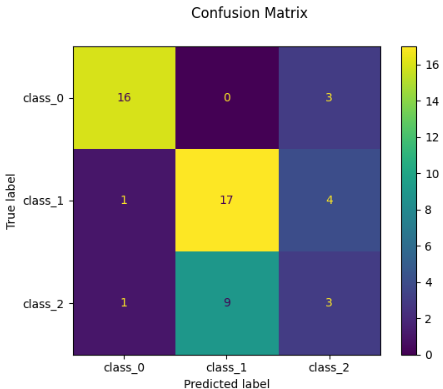

In den Zeilen findet man die tatsächlichen Werte und in den Spalten die Vorhersagen. 

Die Felder zeigen dementsprechend die vier mögliche Ergebnisse einer Klassifikation:

- `True Positives (TP)`: Richtig erkannte positive Fälle.
- `False Positives (FP)`: Fälschlich als positiv klassifizierte negative Fälle.
- `True Negatives (TN)`: Richtig erkannte negative Fälle.
- `False Negatives (FN)`: Fälschlich als negativ klassifizierte positive Fälle.


Um die Leistung eines Modells genauer zu beurteilen, können aus den Feldern der Confusion Matrix zwei Kennzahlen ermittelt werden:  

> `Recall und Precision`.  

Beide spielen eine wesentliche Rolle, besonders in Situationen, in denen Fehler unterschiedliche Kosten verursachen (z.B. bei medizinischen Diagnosen oder Betrugserkennung).


> ##### `Precision (Genauigkeit):`
>Precision misst die Genauigkeit der positiven Vorhersagen. Es zeigt, **wie viele der als positiv klassifizierten Fälle tatsächlich positiv sind**.
>
> ##### $\text{Precision} = \frac{\text{Wahr Positive (TP)}}{\text{Wahr Positive (TP)} + \text{Falsch Positiv (FP)}} $
>
> Ein hoher Precision-Wert bedeutet, dass das Modell nur dann eine positive Vorhersage trifft, wenn es sich sehr sicher ist, dass die Vorhersage richtig ist,` aber es kann dabei einige positive Instanzen übersehen`.



> ##### `Recall (Trefferquote, Sensitivität)`:
> Recall misst, wie gut das Modell alle relevanten positiven Fälle findet. Es zeigt den Anteil **der tatsächlichen positiven Fälle, die vom Modell korrekt als positiv klassifiziert wurden**.
>
> ##### $\text{Sensitivität} = \frac{\text{Wahr Positive (TP)}}{\text{Wahr Positive (TP)} + \text{Falsch Negative (FN)}} $
> 
> Ein hoher Recall bedeutet, dass das Modell fast alle relevanten positiven Instanzen gefunden hat, `aber möglicherweise auch einige falsche positive Vorhersagen gemacht hat`.


##### ✨ `Abwägung zwischen Precision und Recall:`
In vielen Fällen gibt es eine Abwägung zwischen Precision und Recall. Wenn man den Recall maximiert (alle relevanten Fälle findet), kann die Precision leiden (mehr falsche positive Ergebnisse). Umgekehrt kann eine hohe Precision oft mit einem niedrigeren Recall einhergehen.

Beispiel:

**Hoher Recall, niedrige Precision**:  
Du möchtest sicherstellen, dass keine positiven Fälle übersehen werden, auch wenn einige falsche Positive auftreten (z.B. in der Früherkennung von Krankheiten).

**Hohe Precision, niedriger Recall**:  
Du möchtest nur die Fälle kennzeichnen, bei denen du dir sicher bist, auch wenn du dabei einige positive Fälle verpasst (z.B. bei einem Betrugserkennungsalgorithmus, der nur sehr sichere Fälle markieren soll).


Insgesamt hängen die Wahl und die Bedeutung dieser Metriken von den spezifischen Anforderungen der Aufgabe ab.




<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Erstellen einer detailierten Evaluierung des Modells mit

- einer ``Confusion-Matrix`` und
- eines ``Classification Reports``

---

---
# 🟨 ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_wine` verwendet.

In [ ]:
from sklearn import datasets
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
dfWine, target = datasets.load_wine( return_X_y=True, as_frame=True )

dfWine['class'] = target.replace({0:'class_0',1:'class_1', 2:'class_2'})

dfWine.head()

---
# 🟨 ``Schritt 2:`` Data Preprocessing


### Daten auswählen

Erstellen eines Dataframes mit den Fetures, welche für die Vorhersage verwendet werden sollen und eines für das Feature, welches vorhergesagt werden soll.


In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['proline', 'hue']  # independent
cols_y  = 'class'             # dependent: Vorhersagen

#------------------------------------------------------------
dfLearn_X = dfWine[cols_x]
dfLearn_Y = dfWine[cols_y]

### Features Skalieren

In [ ]:
#-------------------------------------------------------------
# Führe später die Übung ein weiteres mal mit skalierten Daten durch
# ---> Dein Code 



### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
train_x, test_x, train_y, test_y = train_test_split( dfLearn_X, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x = train_x.values       # independent
train_y = train_y.values       # dependent

test_x  = test_x.values        # independent
test_y  = test_y.values        # dependent
#------------------------------------------------------------

---
# 🟨 ``Schritt 3:`` Modell erstellen und trainieren



### Modell erstellen und trainieren



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

#------------------------------------------------------------
# Modell erstellen und trainieren
k = 2  # nächsten Nachbarn festlegen

model = KNeighborsClassifier(n_neighbors = k)
model.fit(train_x, train_y)

### Vorhersagen erstellen
Erstelle mit dem trainierten Modell nun für die Trainings- und Testdaten die jeweiligen Vorhersagen.


In [ ]:
#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)

---
# 🟨 ``Schritt 4:`` Detailierte Evaluierung


## 🔷 Confusionmatrix
Evaluiere das Model anhand einer Confusion Matrix. Gib die Confusion Matrix dazu graphisch aus.


In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics

# Grafische Confusion Matrix ausgeben
labels = model.classes_
disp = metrics.ConfusionMatrixDisplay.from_predictions(
                test_y, pred_y,
                display_labels=labels) 

disp.figure_.suptitle("Confusion Matrix")

plt.show()

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Erläutere und bewerte das Ergebnis der Matrix?  
 Begründe deine Antwort!**<br>  
  
##### ✨ Diagonale Werte (**richtige** Klassifikationen):
- ``Class_0``:<br> Von den insgesamt 19 Fällen (16+0+3), in denen die wahre Klasse class_0 war, wurden 16 korrekt als class_0 vorhergesagt.  
**Dies ist eine hohe Treffergenauigkeit.**
- ``Class_1``:<br> Von den insgesamt 22 Fällen (1+17+4), in denen die wahre Klasse class_1 war, wurden 17 korrekt als class_1 vorhergesagt.
- ``Class_2``:<br> Von den insgesamt 13 Fällen (1+9+3), in denen die wahre Klasse class_2 war, wurden nur 9 korrekt als class_2 vorhergesagt.  
**Diese Klasse hat eine niedrigere Treffergenauigkeit verglichen mit den anderen Klassen.**

##### ✨ Nicht-diagonale Werte (**falsche** Klassifikationen):
- ``Class_0`` wurde nie fälschlicherweise für Class_1 vorhergesagt (0 Fälle).
- ``Class_1`` wurde einmal fälschlicherweise als Class_0 vorhergesagt und viermal als Class_2.
- ``Class_2`` wurde ebenfalls einmal fälschlicherweise als Class_0 vorhergesagt und dreimal als Class_2.


##### ✨ Analyse der Fehler und Maßnahmen:

- ``Class_0 und Class_1`` zeigen **eine gute Trennung**,  
da es keine Fälle gibt, in denen Class_0 fälschlicherweise als Class_1 vorhergesagt wurde und umgekehrt.

- ``Class_2`` hat eine **höhere Rate an falsch positiven und falsch negativen Vorhersagen**.  
Dies könnte auf eine Überlappung der Merkmale von Class_2 mit denen der anderen beiden Klassen hinweisen oder darauf, dass die Merkmale, die Class_2 definieren, nicht deutlich genug im Modell repräsentiert sind.


``Das Modell sollte weiter optimiert werden mit mehr Daten oder ein überarbeiten der verwendeten Feature.``

---
</div>

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Beschreibe was du über die Precision des Models aus der Matrix entnehmen kannst?  
 Begründe deine Antwort!**<br>  

Diese Präzisionswerte helfen dabei, zu verstehen, wie gut das Modell in der Lage ist, korrekte Vorhersagen zu liefern, ohne durch falsche Positivmeldungen gestört zu werden, insbesondere in einem unbalancierten Datensatz, wo einige Klassen häufiger auftreten können als andere.

##### ✨ $\text{Precision} = \frac{\text{Wahr Positive (TP)}}{\text{Wahr Positive (TP)} + \text{Falsch Positiv (FP)}} $

1. ``Precision für Class_0``:<br>
   Hier sind die TP für Class_0 = 16 (Fälle korrekt als Class_0 identifiziert).<br>
   Die FP für Class_0 sind die Summe der Fälle, in denen andere Klassen fälschlicherweise als Class_0 vorhergesagt wurden, das heißt 1 (Class_1 als Class_0) + 1 (Class_2 als Class_0) = 2.
   
   $\text{Precision für Class 0} = \frac{16}{16 + 2} = \frac{16}{18} \approx 0.89 $
   

2. ``Precision für Class_1``:<br>
   TP für Class_1 = 17.<br>
   Die FP für Class_1 sind die Fälle, in denen andere Klassen fälschlicherweise als Class_1 vorhergesagt wurden, also 0 (Class_0 als Class_1) + 9 (Class_2 als Class_1) = 9.
   
   $\text{Precision für Class 1} = \frac{17}{17 + 9} = \frac{17}{26} \approx 0.65 $

3. ``Precision für Class_2``:<br>
   TP für Class_2 = 9.<br>
   Die FP für Class_2 sind die Fälle, in denen andere Klassen fälschlicherweise als Class_2 vorhergesagt wurden, also 3 (Class_0 als Class_2) + 4 (Class_1 als Class_2) = 7.
   
   $\text{Precision für Class 2} = \frac{9}{9 + 7} = \frac{9}{16} \approx 0.56$
   

### Zusammenfassung
- ``Class_0 hat die höchste Precision``<br> 
(etwa 0.89), was bedeutet, dass wenn das Modell vorhersagt, dass ein Fall Class_0 ist, es sehr wahrscheinlich richtig ist.
- ``Class_1 und Class_2 haben niedrigere Precision-Werte``<br> 
(0.65 und 0.56), was darauf hindeutet, dass Vorhersagen in diesen Klassen weniger verlässlich sind und häufiger falsche Positivmeldungen aufweisen.

---
</div>

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Beschreibe was du über die Sensibilität des Models aus der Matrix entnehmen kannst?  
Begründe deine Antwort!**<br>  

Diese Recall-Werte sind besonders wichtig, um die Fähigkeit des Modells zu bewerten, keine Fälle der jeweiligen Klasse zu übersehen, was in bestimmten Anwendungsfällen (z.B. bei der Krankheitserkennung) kritisch sein kann.


##### ✨ $\text{Sensitivität} = \frac{\text{Wahr Positive (TP)}}{\text{Wahr Positive (TP)} + \text{Falsch Negative (FN)}} $


1. ``Sensibilität für Class_0``:<br> 
   TP für Class_0 = 16.<br> 
   FN für Class_0 sind die Fälle, in denen Class_0 fälschlicherweise als eine andere Klasse klassifiziert wurde, das heißt 0 (als Class_1 klassifiziert) + 3 (als Class_2 klassifiziert) = 3.
   
   $\text{Sensibilität für Class 0} = \frac{16}{16 + 3} = \frac{16}{19} \approx 0.84$
   

2. ``Sensibilität für Class_1``:<br>
   TP für Class_1 = 17.<br> 
   FN für Class_1 sind die Fälle, in denen Class_1 fälschlicherweise als eine andere Klasse klassifiziert wurde, das heißt 1 (als Class_0 klassifiziert) + 4 (als Class_2 klassifiziert) = 5.
   
   $\text{Sensibilität für Class 1} = \frac{17}{17 + 5} = \frac{17}{22} \approx 0.77$
   

3. ``Sensibilität für Class_2``:<br>
   TP für Class_2 = 9.<br> 
   FN für Class_2 sind die Fälle, in denen Class_2 fälschlicherweise als eine andere Klasse klassifiziert wurde, das heißt 1 (als Class_0 klassifiziert) + 3 (als Class_1 klassifiziert) = 4.
   
   $\text{Sensibilität für Class 2} = \frac{9}{9 + 4} = \frac{9}{13} \approx 0.69$

### Zusammenfassung
- ``Class_0 hat die höchste Sensibilität``<br> 
(ungefähr 0.84), was bedeutet, dass das Modell gut darin ist, tatsächliche Fälle von Class_0 zu erkennen und als solche zu klassifizieren.
- ``Class_1 hat eine mittlere Sensibilität``<br> 
(ungefähr 0.77), was darauf hinweist, dass das Modell die meisten, aber nicht alle Fälle von Class_1 korrekt identifiziert.
- ``Class_2 hat die niedrigste Sensibilität``<br> 
(ungefähr 0.69), was bedeutet, dass das Modell den größten Schwierigkeiten hat, alle tatsächlichen Fälle von Class_2 korrekt zu identifizieren.





---
</div>

---
## 🔷 Classification Report

Mit dem **``metrics.classification_report``** kann ein Bericht über die Genauigkeit des Modells erstellt werden.

Dazu wird 
- die ``Precision``
- der ``Recall`` und
- der ``F1-Score``

für jede Kategorie ermittelt.


Auf Grundlage der Anzahl der richtigen und falschen Vorhersagen kann nun die ``precision`` und der ``recall`` für jede Klasse berechnet werden:

*   **Precision** ist ein Maß für die Genauigkeit, mit der ein Ergebnis vorhergesagt wurde :   $precision = TP / (TP + FP)$

*   **Recall** ist ein Maß für die Empfindlichkeit des Models:   $recall =  TP / (TP + FN)$

*   **F1 score:** Aus precision und recall kann nun für jede Klasse der F1-Score ermittelt werden. $F1=2*precision*recall /(precision+recall)$


Je näher dieser bei 1 liegt, umso genauer ist das Model.
Aus den F1-Scores kann wiederum die ``durchschnittliche Genauigkeit`` des Models ermittelt werden.


In [ ]:
from sklearn import metrics

print (metrics.classification_report(test_y, pred_y))

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Beschreibe was du über die Genauigkeit der Vorhersagen des Models aus dem Report entnehmen kannst?**<br>  
- Welche Werte werden besonders genau vorhergesagt?
- Welche nicht?  

**Begründe deine Antwort!**<br>  
  
- ``Klasse 0``<br> zeigt die beste Leistung mit einem F1-Score von 0.86, was auf eine relativ hohe Balance zwischen Präzision (0.89) und Recall (0.84) hinweist.
- ``Klasse 1``<br> hat einen mittleren F1-Score von 0.71, mit einer Präzision von 0.65 und einem Recall von 0.77. Dies deutet darauf hin, dass das Modell einige wahre Positive gut identifiziert, aber auch eine moderate Anzahl falscher Negativer und Positiver hat.
- ``Klasse 2``<br> hat einen deutlich niedrigeren F1-Score von 0.26, was auf eine schlechte Leistung hinweist, mit einer niedrigen Präzision (0.30) und Recall (0.23). Dies könnte bedeuten, dass das Modell Schwierigkeiten hat, diese Klasse genau zu identifizieren und von den anderen Klassen zu unterscheiden.


Die Genauigkeit (Accuracy) des Modells beträgt 0.67, was bedeutet, dass das Modell insgesamt 67% der Zeit korrekt klassifiziert.


**``Klasse 2 benötigt Aufmerksamkeit:``**<br> 
Die deutlich schlechtere Leistung in Klasse 2 könnte verbessert werden, indem man das Modell spezifisch für diese Klasse trainiert, möglicherweise durch Sammeln mehr Daten, Anwenden von Techniken wie Oversampling oder spezifischeren Feature-Engineering.


---
</div>

---
## 🔷 Precision-Recall-Kurve

 Verwende dafür den **``metrics.PrecisionRecallDisplay.from_predictions``**

Die Precision-Recall-Curve ist ein Diagramm, das die Beziehung zwischen Precision (Genauigkeit) und Recall (Trefferquote) für verschiedene Schwellenwerte eines Klassifikationsmodells darstellt. Anhand dieser Kurve können mehrere wichtige Erkenntnisse gewonnen werden:

- Modell-Leistung:  
Eine steil ansteigende Kurve deutet auf ein leistungsfähiges Modell hin. Ein Modell mit hoher Precision und Recall in allen Bereichen wird durch eine Kurve nahe am oberen rechten Eck dargestellt.

- Abwägung von Precision und Recall:  
Die Kurve hilft, die Balance zwischen Precision und Recall zu verstehen, besonders bei unbalancierten Datensätzen oder wenn falsche positive/negative Vorhersagen unterschiedliche Kosten haben.

- Area Under the Curve (AUC):  
Die Fläche unter der Precision-Recall-Kurve (PR AUC) fasst die Modellleistung zusammen. Ein höherer AUC-Wert bedeutet eine bessere Trennung zwischen positiven und negativen Klassen.



In [ ]:
# ---> Dein Code

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

precision = dict()
recall = dict()
classes = model.classes_
n_classes = len(classes)

display_labels=model.classes_

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(test_y==classes[i], pred_y==classes[i])
    plt.plot(recall[i], precision[i], lw=2, label=display_labels[i])

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve für multiklassige Vorhersagen')
plt.legend(loc="best")
plt.show()